# Plot Evolution of Cells

Loaded data from filtered_free_cells_202105_1km.csv with 1770 rows.
Error reading filtered_free_cells_202106_1km.csv: [Errno 2] No such file or directory: 'filtered_free_cells_202106_1km.csv'
Loaded data from filtered_free_cells_202107_1km.csv with 1033 rows.
Loaded data from filtered_free_cells_202108_1km.csv with 19640 rows.
Loaded data from filtered_free_cells_202109_1km.csv with 9310 rows.
Loaded data from filtered_free_cells_202205_1km.csv with 2098 rows.
Loaded data from filtered_free_cells_202206_1km.csv with 4816 rows.
Loaded data from filtered_free_cells_202207_1km.csv with 12177 rows.
Loaded data from filtered_free_cells_202208_1km.csv with 23665 rows.
Loaded data from filtered_free_cells_202209_1km.csv with 11799 rows.
Loaded data from filtered_free_cells_202305_1km.csv with 6816 rows.
Loaded data from filtered_free_cells_202306_1km.csv with 4226 rows.
Loaded data from filtered_free_cells_202307_1km.csv with 9113 rows.
Loaded data from filtered_free_cells_202308_1km.csv with

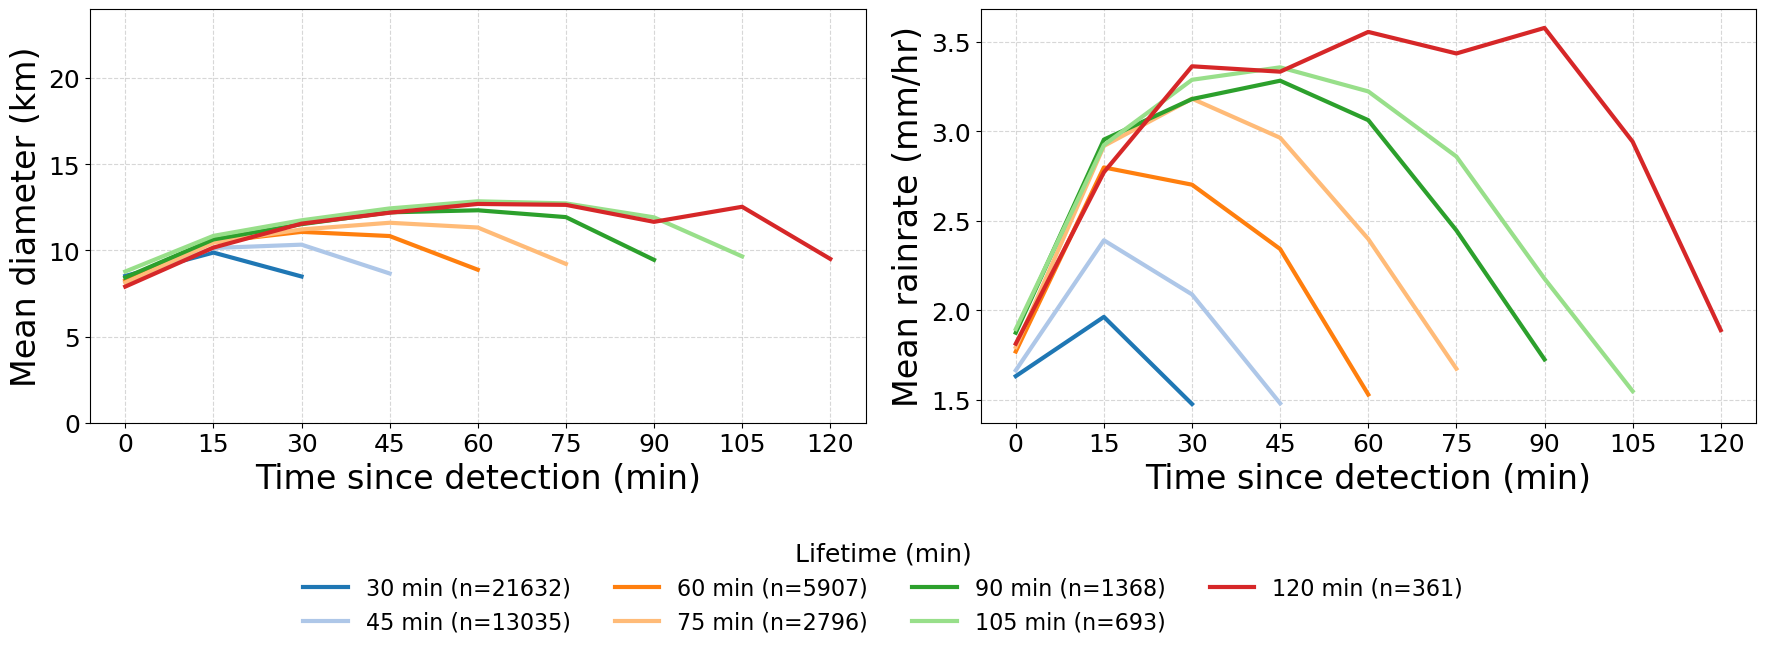

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Paper-style plot settings (bigger fonts)
# =========================
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 24,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
    "figure.titlesize": 20
})

# ----------------------------
# Define years and months to process
# ----------------------------
years = ["2021", "2022", "2023", "2024"]
months = ["05", "06", "07", "08", "09"]

# ----------------------------
# Load all CSVs and combine
# ----------------------------
dfs = []
for year in years:
    for month in months:
        csv_file = f"filtered_free_cells_{year}{month}_1km.csv"
        try:
            df_month = pd.read_csv(csv_file)
            print(f"Loaded data from {csv_file} with {len(df_month)} rows.")
            df_month["year"] = year
            df_month["month"] = month
            df_month["unique_cell"] = (
                df_month["year"] + "_" + df_month["month"] + "_" + df_month["cell"].astype(str)
            )
            dfs.append(df_month)
        except Exception as e:
            print(f"Error reading {csv_file}: {e}")

if not dfs:
    raise ValueError("No data loaded. Check your file paths and names.")

df = pd.concat(dfs, ignore_index=True)
print(f"Combined dataset has {len(df)} rows.")

# ----------------------------
# Preprocessing
# ----------------------------
df["time_cell"] = pd.to_timedelta(df["time_cell"])
df["time_minutes"] = df["time_cell"].dt.total_seconds() / 60.0

# Convert precip from mm/day -> mm/hr
df["mean_precip_mmhr"] = df["mean_precip"] / 24.0

# Compute lifetime per cell
cell_lifetime = (
    df.groupby("unique_cell")["time_minutes"]
      .max()
      .reset_index()
      .rename(columns={"time_minutes": "lifetime"})
)
df = df.merge(cell_lifetime, on="unique_cell", how="left")

# Bin lifetimes into 15-min bins
df["lifetime_rounded"] = (df["lifetime"] // 15) * 15
unique_lifetimes = sorted(df["lifetime_rounded"].dropna().unique())
print("Unique lifetime bins (min):", unique_lifetimes)

# ----------------------------
# High-contrast discrete color set
# ----------------------------
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_lifetimes)))

# ----------------------------
# Create side-by-side plots
# ----------------------------
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6), sharex=True)

min_cells = 200
handles, labels = [], []

# Diameter plot
for i, lifetime in enumerate(unique_lifetimes):
    df_subset = df[df["lifetime_rounded"] == lifetime].copy()
    sample_count = df_subset["unique_cell"].nunique()
    if sample_count < min_cells:
        continue

    df_subset["time_bin"] = (df_subset["time_minutes"] // 15) * 15
    diameter_evolution = df_subset.groupby("time_bin")["diameter_km"].mean().reset_index()

    line, = axes[0].plot(
        diameter_evolution["time_bin"],
        diameter_evolution["diameter_km"],
        linestyle="-",
        color=colors[i],
        linewidth=3
    )
    handles.append(line)
    labels.append(f"{int(lifetime)} min (n={sample_count})")

axes[0].set_xlabel("Time since detection (min)")
axes[0].set_ylabel("Mean diameter (km)")
axes[0].set_ylim(0, 24)
axes[0].xaxis.set_major_locator(plt.MultipleLocator(15))
axes[0].grid(True, linestyle="--", alpha=0.5)

# Precipitation plot (mm/hr)
for i, lifetime in enumerate(unique_lifetimes):
    df_subset = df[df["lifetime_rounded"] == lifetime].copy()
    sample_count = df_subset["unique_cell"].nunique()
    if sample_count < min_cells:
        continue

    df_subset["time_bin"] = (df_subset["time_minutes"] // 15) * 15
    precip_evolution = df_subset.groupby("time_bin")["mean_precip_mmhr"].mean().reset_index()

    axes[1].plot(
        precip_evolution["time_bin"],
        precip_evolution["mean_precip_mmhr"],
        linestyle="-",
        color=colors[i],
        linewidth=3
    )

axes[1].set_xlabel("Time since detection (min)")
axes[1].set_ylabel("Mean rainrate (mm/hr)")
axes[1].xaxis.set_major_locator(plt.MultipleLocator(15))
axes[1].grid(True, linestyle="--", alpha=0.5)

# Shared legend below
ncol = 4 if len(labels) > 4 else len(labels)
fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=ncol,
    frameon=False,
    title="Lifetime (min)"
)

plt.tight_layout(rect=[0, 0.10, 1, 1])

plt.savefig("side_by_side_diameter_precipRATE_mmhr_legendbelow.png",
            dpi=300, bbox_inches="tight")
plt.show()